In [27]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./train.csv")
test_df = pd.read_csv("./test.csv")

print(df["Id"].size)
print(test_df["Id"].size)

1460
1459


In [28]:
targetFeature = 'SalePrice'

print("=== Первые несколько записей ===")
print(df.head())

print("\n === Статистика данных ===")
print(df.describe())

print("\n === Типы данных ===")
print(df.dtypes)

=== Первые несколько записей ===
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  

In [29]:
print("\n === Проверка и кодирование строк ===")

def encodeDataTypes(df):
    non_numeric_cols = df.select_dtypes(exclude=['number'])
    le = LabelEncoder()
    for col in non_numeric_cols:
        print(f"Всего уникальных {col}: {df[col].nunique()}")
        print(f"Обрабатываю колонку {col}")
        df[col] = le.fit_transform(df[col])

encodeDataTypes(df)
encodeDataTypes(test_df)



 === Проверка и кодирование строк ===
Всего уникальных MSZoning: 5
Обрабатываю колонку MSZoning
Всего уникальных Street: 2
Обрабатываю колонку Street
Всего уникальных Alley: 2
Обрабатываю колонку Alley
Всего уникальных LotShape: 4
Обрабатываю колонку LotShape
Всего уникальных LandContour: 4
Обрабатываю колонку LandContour
Всего уникальных Utilities: 2
Обрабатываю колонку Utilities
Всего уникальных LotConfig: 5
Обрабатываю колонку LotConfig
Всего уникальных LandSlope: 3
Обрабатываю колонку LandSlope
Всего уникальных Neighborhood: 25
Обрабатываю колонку Neighborhood
Всего уникальных Condition1: 9
Обрабатываю колонку Condition1
Всего уникальных Condition2: 8
Обрабатываю колонку Condition2
Всего уникальных BldgType: 5
Обрабатываю колонку BldgType
Всего уникальных HouseStyle: 8
Обрабатываю колонку HouseStyle
Всего уникальных RoofStyle: 6
Обрабатываю колонку RoofStyle
Всего уникальных RoofMatl: 8
Обрабатываю колонку RoofMatl
Всего уникальных Exterior1st: 15
Обрабатываю колонку Exterior1st
В


 === Heatmap для просмотра корреляции данных (Все данные)===


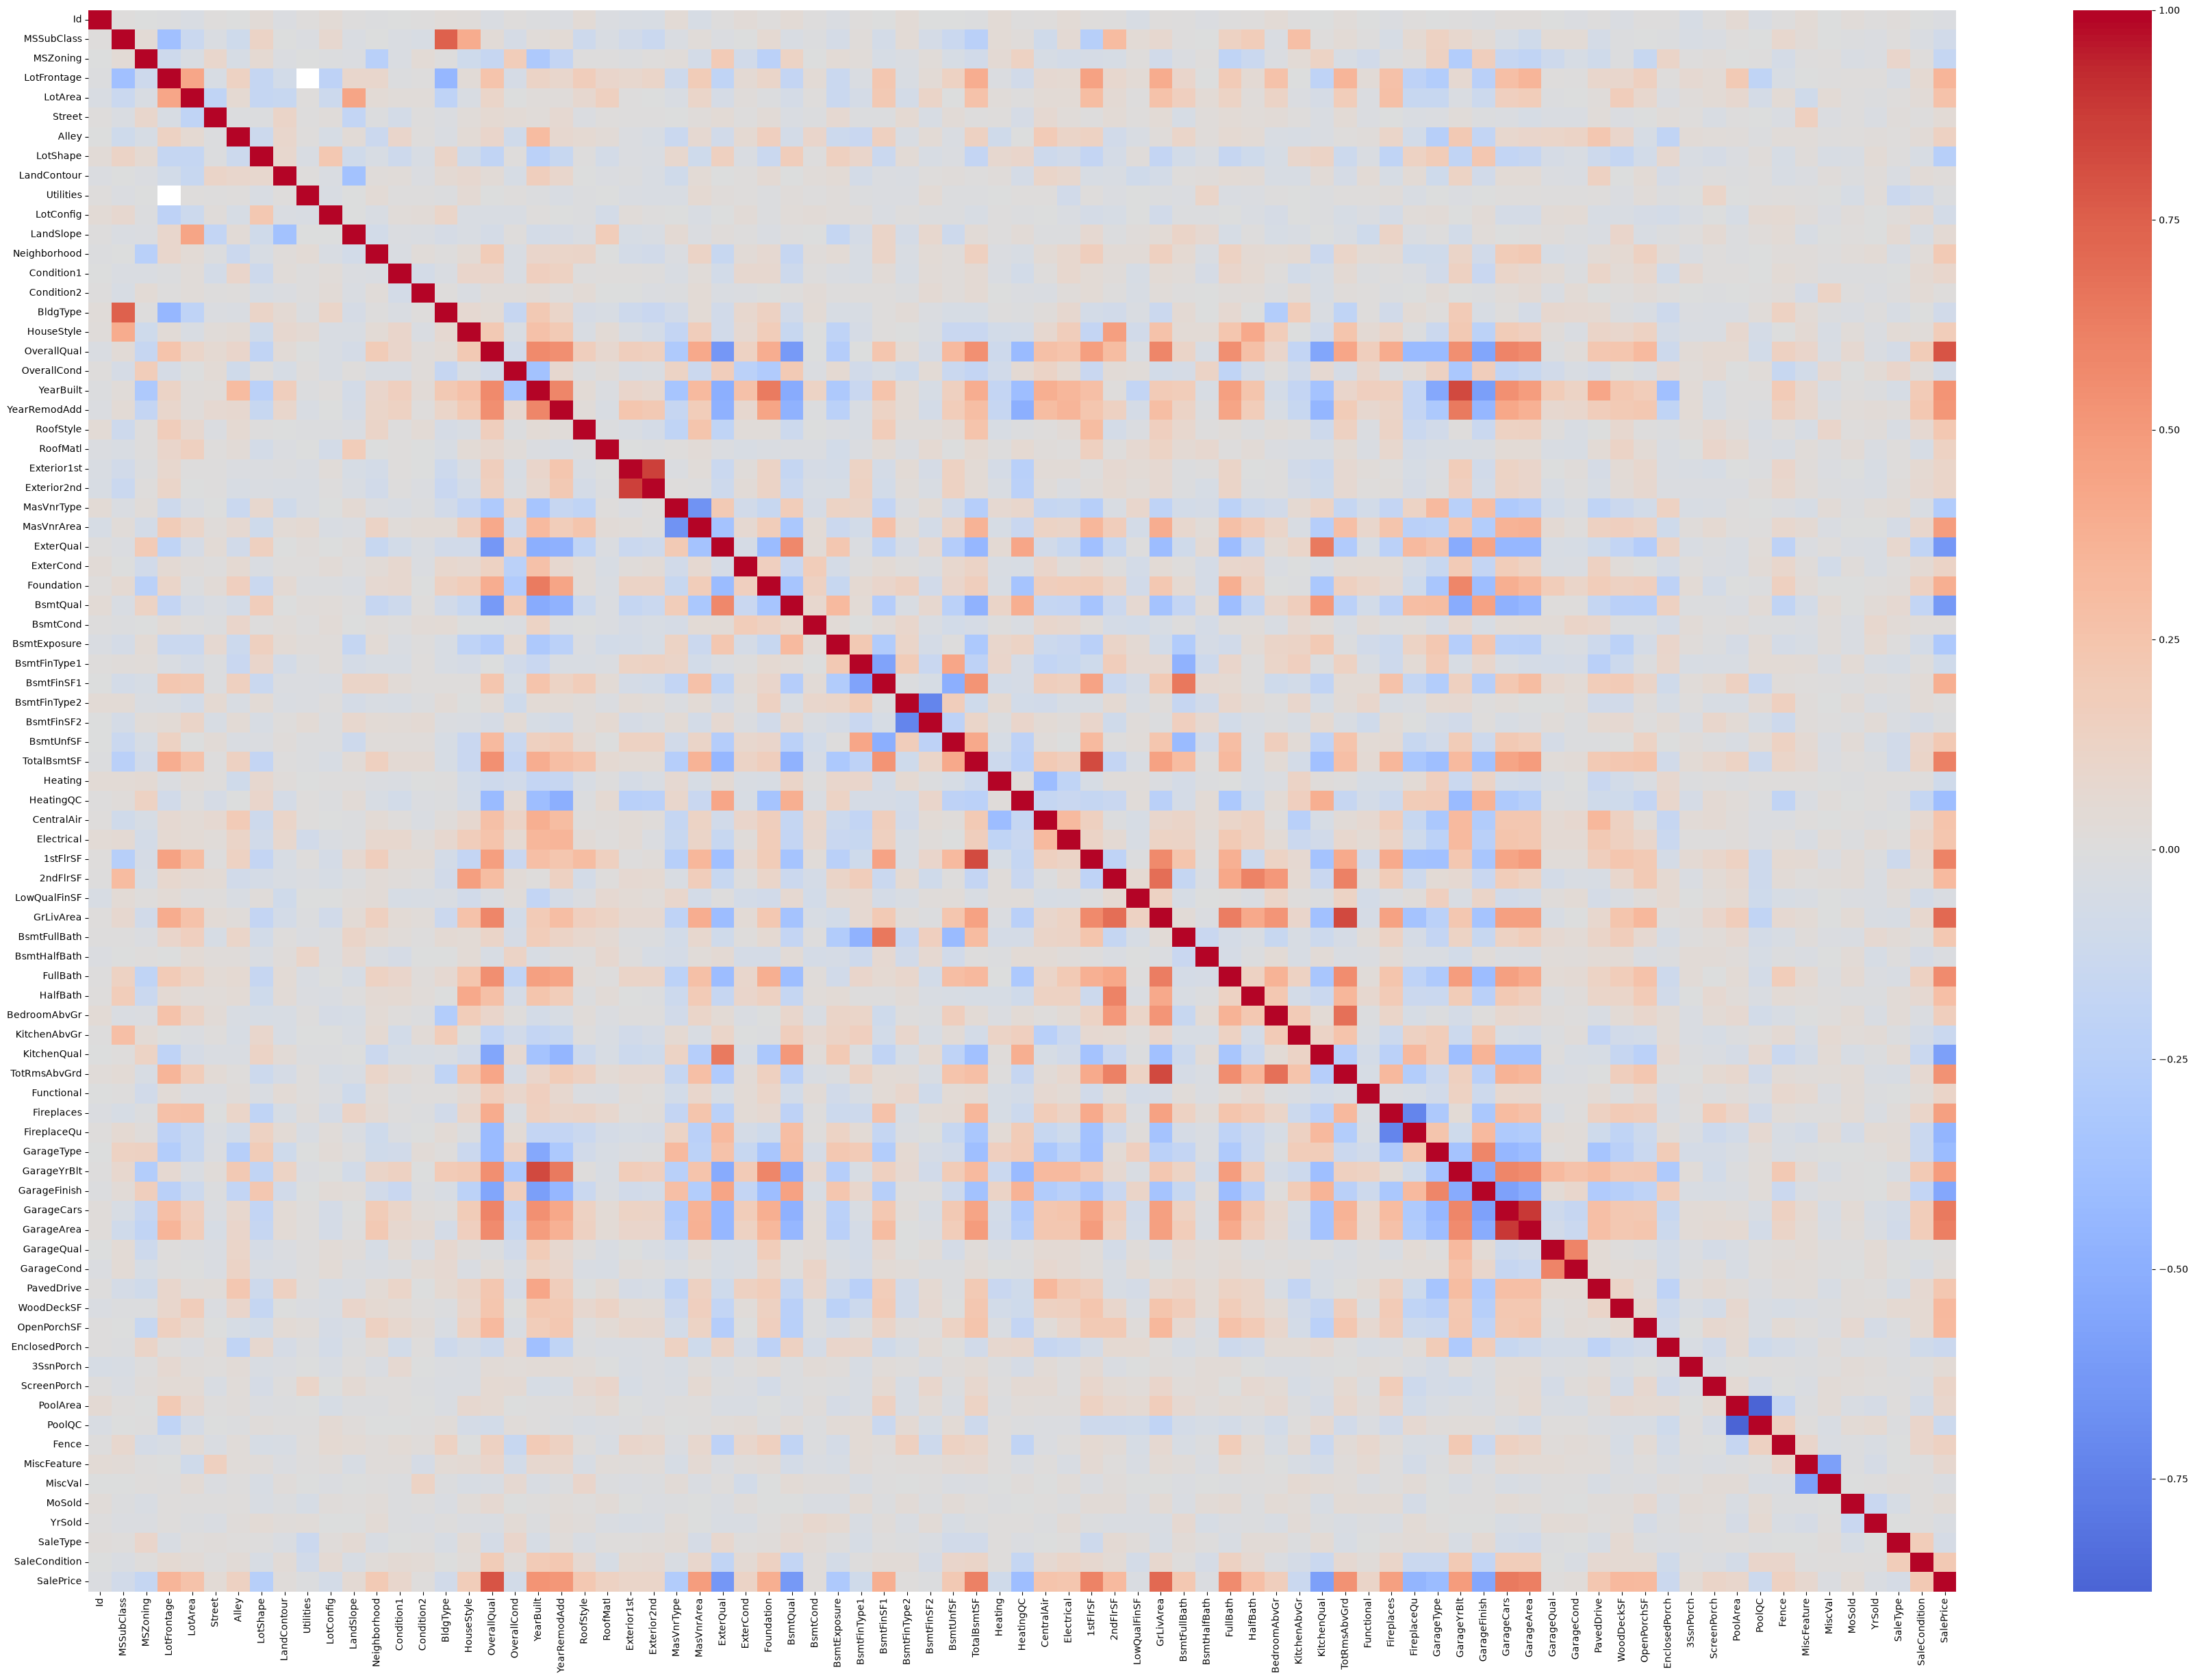

In [30]:
print("\n === Heatmap для просмотра корреляции данных (Все данные)===")
corr = df.corr() # Строим корреляционную матрицу

plt.figure(figsize=(44, 30))
sns.heatmap(corr, annot=False, cmap='coolwarm', center = 0)
plt.show()

In [31]:
import numpy as np

print("\n=== Объединяем некоторые столбцы ===")


def featureEngineere(df):
    # Объединяем метраж этажей
    df['TotalFlrSF'] = df[['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF']].fillna(0).sum(axis=1)
    df = df.drop(['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF'], axis=1)

    # Объединяем состояние двора
    outside_cols = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea']
    df['TotalUsefulOutsideSF'] = df[outside_cols].fillna(0).sum(axis=1)
    df = df.drop(outside_cols, axis=1)

    # Получаем возраст дома на момент продажи 
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    # Свежий ли ремонт
    df["IsNewlyRemodeled"] = np.where(
        (df["YearBuilt"] == df["YearRemodAdd"]) | (df["YrSold"] - df["YearRemodAdd"] > 5),
        0,
        1
    )

featureEngineere(df)
featureEngineere(test_df)


=== Объединяем некоторые столбцы ===


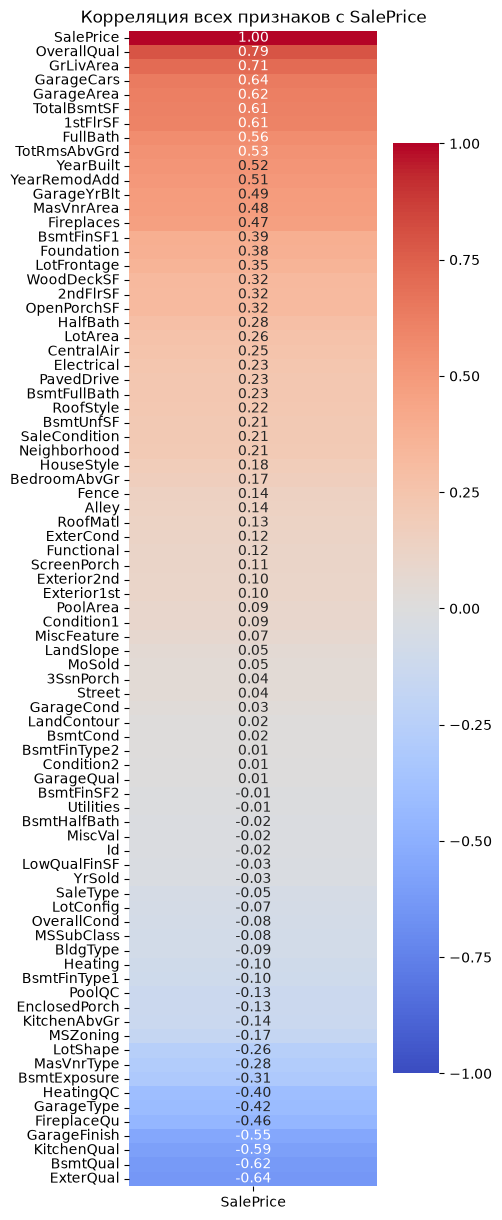

In [32]:
sorted_corr = corr[[targetFeature]].sort_values(by=targetFeature, ascending=False)

plt.figure(figsize=(4, 15))
sns.heatmap(sorted_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title(f'Корреляция всех признаков с {targetFeature}')
plt.show()

Т.к. ищем цену продажи, то можно отбросить признаки, которые почти не влияют ни итоговую цену (По модулю корреляция < 0.1)

In [33]:
corr = df.corr() # Повторно строим корреляционную матрицу после Feature инжира
target_corr = corr[targetFeature]

low_corr_columns = []

for idx, entry in target_corr.items():
    if abs(entry) < 0.1 and "Id" != idx:
        low_corr_columns.append(idx)

print(f"Данные столбцы мало влияют сами по себе на интересующий столбец: \n {low_corr_columns}")

print("Удаляю эти столбцы...")
df = df.drop(low_corr_columns, axis=1)
test_df = test_df.drop(low_corr_columns, axis=1)



Данные столбцы мало влияют сами по себе на интересующий столбец: 
 ['MSSubClass', 'Street', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'OverallCond', 'BsmtCond', 'BsmtFinType2', 'BsmtFinSF2', 'Heating', 'LowQualFinSF', 'BsmtHalfBath', 'GarageQual', 'GarageCond', '3SsnPorch', 'PoolArea', 'MiscFeature', 'MiscVal', 'MoSold', 'YrSold', 'SaleType']
Удаляю эти столбцы...



 === Heatmap после удаления незначительных данных ===


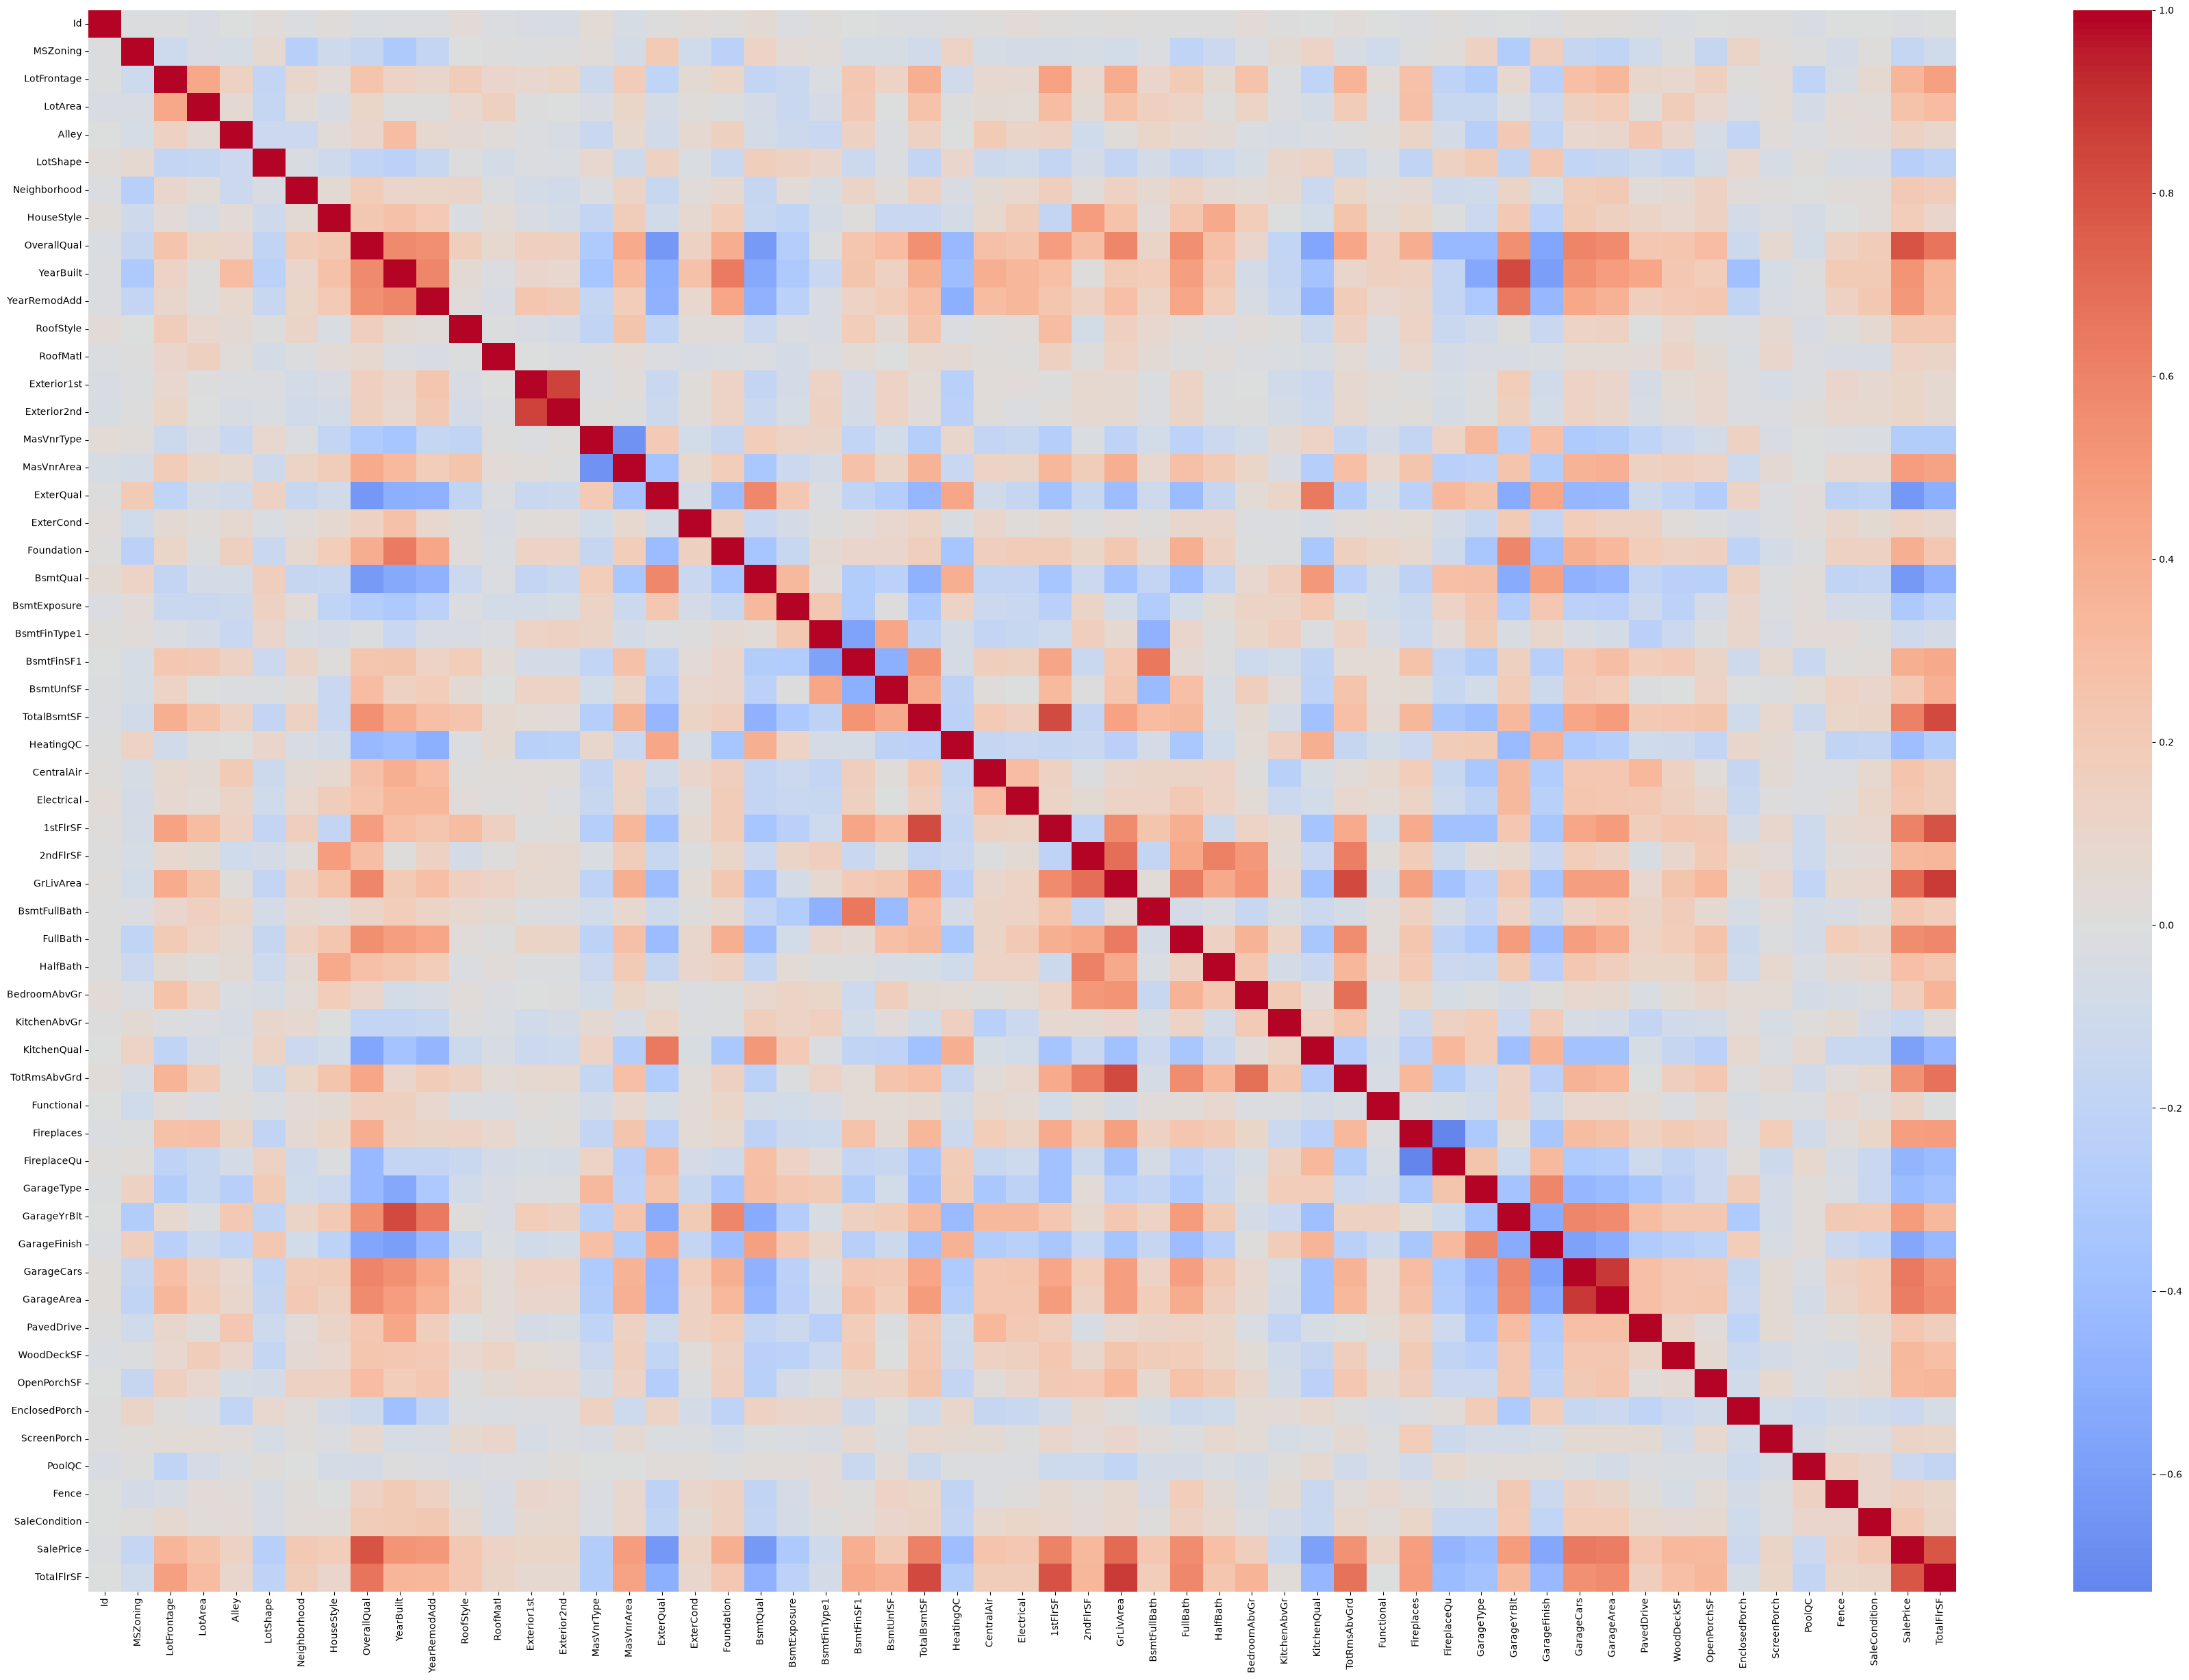

In [34]:
print("\n === Heatmap после удаления незначительных данных ===")
corr = df.corr()

plt.figure(figsize=(44, 30))
sns.heatmap(corr, annot=False, cmap='coolwarm', center = 0)
plt.show()

Начинаем собственно обучать модель

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

y = df[targetFeature]
X = df.drop(columns=targetFeature)

model = RandomForestRegressor(random_state=1610)

param_distributions = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=75,  # Number of parameter settings to sample
    scoring='r2',
    cv=5,  # Number of cross-validation folds
    verbose=2,
    random_state=1610,
    n_jobs=-1  # Use all available CPU cores
)

random_search.fit(X, y)

best_model = random_search.best_estimator_
accuracy = best_model.score(X, y)

predictions = best_model.predict(X)
print("Test Set Accuracy:", accuracy)


Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.4s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.5s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.8s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.8s
[CV] END bootstrap=True, max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.8s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   1.3s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   1.4s
[CV] EN

In [ ]:
# Формирование итогового CSV=
final_predictions = best_model.predict(test_df)

output = pd.DataFrame({'Id': test_df.Id,
                       'SalePrice': final_predictions})
output.to_csv('submission.csv', index=False)

0       1461
1       1462
2       1463
3       1464
4       1465
        ... 
1454    2915
1455    2916
1456    2917
1457    2918
1458    2919
Name: Id, Length: 1459, dtype: int64
